In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd

hpd.util.get_color_logger("INFO")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = (89945, 91552, 440688, 441553) 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 10
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.70it/s]


In [4]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs
name,,,,,,,,,,,,,
GMW000000036741001,90998.687871,441239.318459,MEIJPL-12,,lizard,m NAP,1,-15.680,-16.680,-4.560,-2.680,True,GroundwaterObs GMW000000036741001 -----metadat...
GMW000000036965001,91525.037726,441090.628347,128572-792,,lizard,m NAP,1,-5.970,-6.970,-4.850,-4.970,True,GroundwaterObs GMW000000036965001 -----metadat...
GMW000000036989001,90664.868686,441145.728338,127572-1,,lizard,m NAP,1,-5.150,-7.150,-4.340,-4.350,True,GroundwaterObs GMW000000036989001 -----metadat...
GMW000000037445001,90407.518334,440789.329306,127571-4,,lizard,m NAP,1,-5.390,-7.390,-4.830,-4.890,True,GroundwaterObs GMW000000037445001 -----metadat...
GMW000000038220001,91303.067938,441217.968233,128572-795,,lizard,m NAP,1,-16.560,-18.560,-4.680,-3.560,True,GroundwaterObs GMW000000038220001 -----metadat...
GMW000000098093001,91547.087277,441459.765282,128572-798,,lizard,m NAP,1,-6.807,-7.807,-4.807,-4.884,True,GroundwaterObs GMW000000098093001 -----metadat...
GMW000000101405001,91513.987745,441096.026782,128572-9,,lizard,m NAP,1,-6.410,-7.410,-4.860,-4.860,True,GroundwaterObs GMW000000101405001 -----metadat...
GMW000000101406001,91466.987589,441235.026233,128572-12,,lizard,m NAP,1,-6.390,-7.390,-4.840,-4.840,True,GroundwaterObs GMW000000101406001 -----metadat...
GMW000000101454001,91522.988168,440812.027927,128571-3,,lizard,m NAP,1,-6.390,-7.390,-4.740,-4.740,True,GroundwaterObs GMW000000101454001 -----metadat...


In [5]:
gw = oc.obs["GMW000000036965001"]
print(gw)

GroundwaterObs GMW000000036965001
-----metadata------
name : GMW000000036965001 
x : 91525.03772620695 
y : 441090.6283468774 
location : 128572-792 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -5.97 
screen_bottom : -6.97 
ground_level : -4.85 
tube_top : -4.97 
metadata_available : True 

-----time series------
                     value  flag        comment           origin
peil_datum_tijd                                                 
2011-11-15 00:00:00 -5.960   NaN        Gemeten             hand
2012-01-17 14:58:00 -5.870   NaN        Gemeten             hand
2012-03-12 10:02:00 -5.890   NaN        Gemeten             hand
2012-05-09 23:00:00 -5.760   NaN        Gemeten             hand
2012-07-13 19:59:00 -5.830   NaN        Gemeten             hand
2012-11-05 00:00:00 -5.690   NaN        Gemeten             hand
2013-01-13 17:43:00 -5.790   NaN        Gemeten             hand
2013-02-15 17:58:00 -5.750   NaN        Gemeten             hand
2013-03-0

In [6]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2011-11-15 00:00:00 2025-12-16 01:25:36
(7769,)


In [7]:
ts_year = ts.loc["2024-11-01":"2025-10-31"]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

In [8]:
percentile = 0.30

# === FIXED THRESHOLD ===
threshold_fixed = ts_year.quantile(percentile)

# === VARIABLE THRESHOLD ===
monthly_threshold = (
    ts_year
    .groupby(ts_year.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))          # zorg dat alle maanden bestaan
)

n_months_with_data = monthly_threshold.notna().sum()

if n_months_with_data < 6:
    print(
        f"Not enough data for variable threshold ({n_months_with_data} months). "
        "Variable threshold will not be used."
    )
    threshold_variable_smooth = None
else:
    monthly_threshold = monthly_threshold.interpolate(method="linear")

    threshold_variable = ts_daily.index.to_series().map(
        lambda d: monthly_threshold.loc[d.month]
    )

    threshold_variable_smooth = (
        threshold_variable
        .rolling(window=20, min_periods=1)
        .mean()
    )

# === KIES welke threshold wordt gebruikt voor DROOGTE ===
threshold = threshold_variable_smooth if threshold_variable_smooth is not None else threshold_fixed


In [11]:
is_drought_fixed = ts_daily < threshold_fixed

if threshold_variable_smooth is not None:
    is_drought_variable = ts_daily < threshold_variable_smooth
else:
    is_drought_variable = None

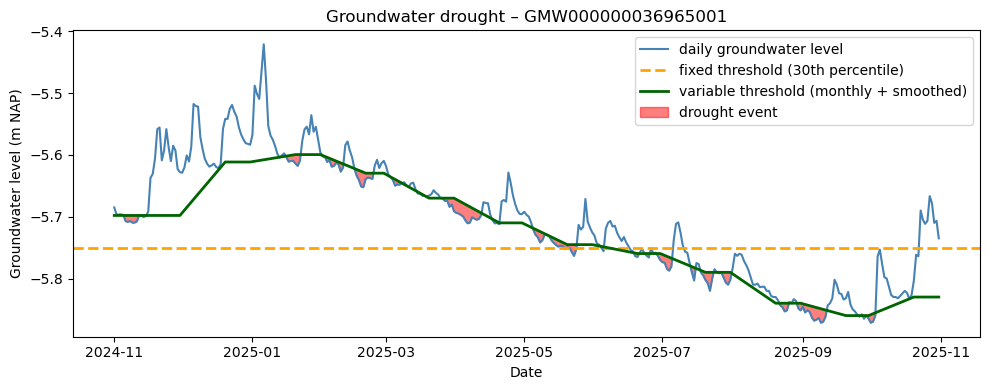

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

# Groundwater level
ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

# Fixed threshold (altijd)
ax.axhline(
    threshold_fixed,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="fixed threshold (30th percentile)",
)

# Variable threshold (alleen als beschikbaar)
if threshold_variable_smooth is not None:
    ax.plot(
        threshold_variable_smooth.index,
        threshold_variable_smooth.values,
        color="darkgreen",
        linewidth=2,
        label="variable threshold (monthly + smoothed)",
    )

# Drought shading (gebaseerd op GEKOZEN threshold)
ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold,
    where=is_drought,
    color="red",
    alpha=0.5,
    label="drought event",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – {gw.name}")
ax.legend()

plt.tight_layout()
plt.show()
